# 🛰️ Aurora — Notebook 04: Environmental Mapping & Biophysical Indices

**Project:** Aurora — Geo Snap Paradigm  
**Objective:** Compute biophysical spectral indices and implement automated pipeline routing.

## Biophysical Index Suite
| Index | Formula | Ecological Role |
|---|---|---|
| NDVI  | (B8-B4)/(B8+B4) | Photosynthetic vegetation vigor |
| EVI2  | 2.5×(B8-B4)/(B8+2.4×B4+1) | Soil-adjusted greenness |
| NDRE  | (B8A-B5)/(B8A+B5) | Red Edge chlorophyll content |
| NDMI  | (B8-B11)/(B8+B11) | Foliar water content / drought |
| NDWI  | (B3-B8)/(B3+B8) | Open water bodies |
| MNDWI | (B3-B11)/(B3+B11) | Water (suppresses urban) |
| NDBI  | (B11-B8)/(B11+B8) | Built-up impervious surface |
| NDSI  | (B3-B11)/(B3+B11) | Snow and ice detection |
| NBR   | (B8-B12)/(B8+B12) | Burn severity |

## Pipeline Routing
- **AnnualCrop / PermanentCrop** → NDVI + NDRE
- **Forest** → NDMI + NDVI (canopy moisture + biomass)
- **Residential / Industrial** → NDBI
- **River / SeaLake** → NDWI + MNDWI

---

In [16]:
# ─── Setup ───────────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from utils import (
    BAND_NAMES, BAND_STATS,
    compute_spectral_indices, INDEX_NAMES, route_pipeline,
    make_false_color, preprocess_ms_patch,
)
from dataset import EUROSAT_CLASSES

plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22'})

MS_ROOT = Path('../Data/EuroSATallBands')
OUTPUT  = Path('../outputs')
OUTPUT.mkdir(exist_ok=True)

DATA_AVAILABLE = MS_ROOT.exists()
print(f'MS Data available: {DATA_AVAILABLE}')
print('✅ Imports successful')

MS Data available: True
✅ Imports successful


In [17]:
# ─── Real MS Patch Loader ─────────────────────────────────────────────────────
import rasterio

def load_real_patch(class_name: str, idx: int = 0, split: str = 'train') -> np.ndarray:
    """Load an actual 13-band Sentinel-2 patch from disk."""
    cls_dir = MS_ROOT / split / class_name
    if not cls_dir.exists():
        raise FileNotFoundError(f"{cls_dir} not found")
    tifs = sorted(cls_dir.glob('*.tif'))
    if not tifs:
        raise FileNotFoundError(f"No .tif files in {cls_dir}")
    with rasterio.open(tifs[idx % len(tifs)]) as src:
        patch = src.read().astype(np.float32)   # (13, 64, 64)
    return patch

def load_class_mean_patch(class_name: str, n: int = 50, split: str = 'train') -> np.ndarray:
    """Average n real patches for a class — smooths noise, keeps spectral truth."""
    cls_dir = MS_ROOT / split / class_name
    tifs = sorted(cls_dir.glob('*.tif'))[:n]
    patches = []
    for f in tifs:
        with rasterio.open(f) as src:
            patches.append(src.read().astype(np.float32))
    return np.stack(patches).mean(axis=0)

# Verify
test = load_real_patch('Forest')
print(f'Real patch shape: {test.shape}  dtype: {test.dtype}')
print(f'Band value range: [{test.min():.1f}, {test.max():.1f}]')
print(f'MS_ROOT: {MS_ROOT.resolve()}')
print("✅ Real data loader ready")


Real patch shape: (13, 64, 64)  dtype: float32
Band value range: [7.0, 5087.0]
MS_ROOT: /Users/aryaveerrana/TeamName_Aurora_submission/Data/EuroSATallBands
✅ Real data loader ready


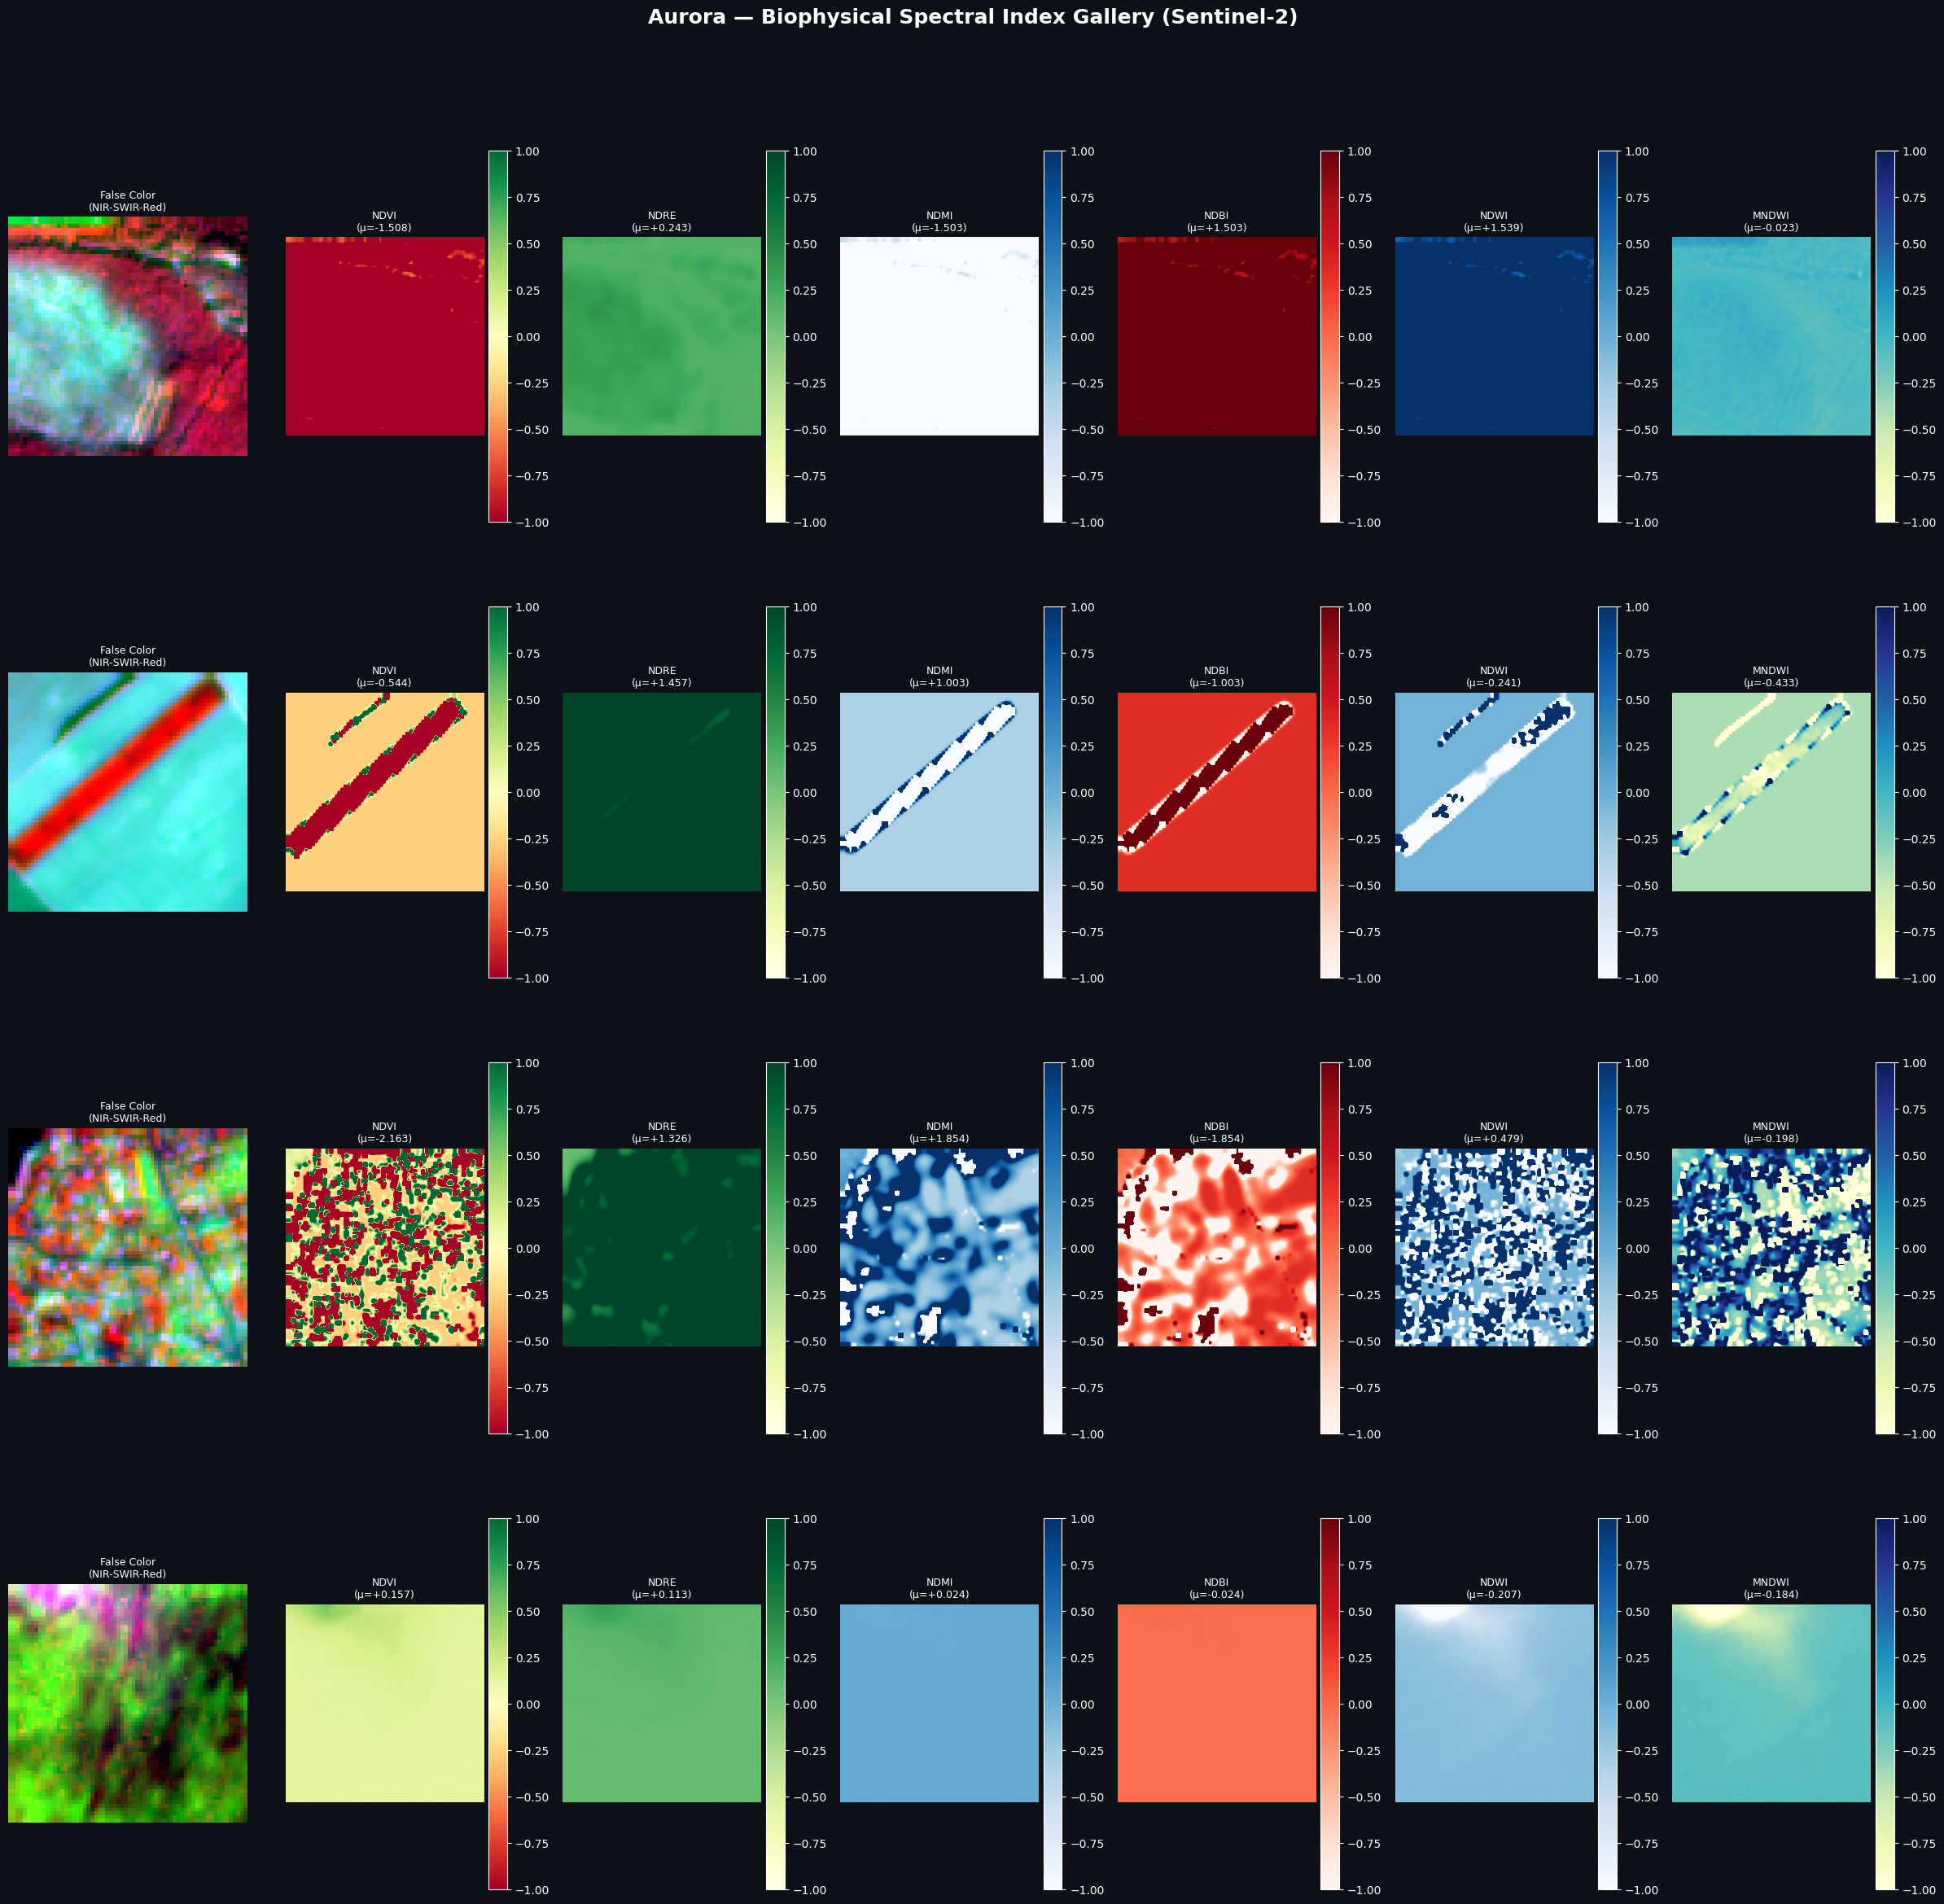

✅ Saved → ../outputs/04_spectral_index_gallery.png


In [18]:
# ─── Section 4A: Spectral Index Gallery ──────────────────────────────────────
def load_or_generate_patch(class_name: str, data_root: Path, seed: int = 42) -> np.ndarray:
    """Load a real TIFF patch or fall back to synthetic."""
    if data_root.exists():
        for split in ['train', 'val']:
            class_dir = data_root / split / class_name
            if class_dir.exists():
                files = list(class_dir.glob('*.tif')) + list(class_dir.glob('*.tiff'))
                if files:
                    import rasterio
                    with rasterio.open(files[seed % len(files)]) as src:
                        raw = src.read().astype(np.float32)[:13]
                    return raw
    raise FileNotFoundError(f"No .tif files found for {class_name} in {data_root}/train or /val")


# Select representative class for each major biome
DEMO_CLASSES = ['Forest', 'AnnualCrop', 'Residential', 'SeaLake']

fig = plt.figure(figsize=(24, 6 * len(DEMO_CLASSES)), facecolor='#0d1117')
fig.suptitle('Aurora — Biophysical Spectral Index Gallery (Sentinel-2)',
             color='white', fontsize=18, fontweight='bold', y=1.01)

CMAPS = {
    'NDVI':  'RdYlGn', 'EVI2': 'Greens', 'NDRE':  'YlGn',
    'NDMI':  'Blues',  'NDWI': 'Blues',  'MNDWI': 'YlGnBu',
    'NDBI':  'Reds',   'NDSI': 'cool',   'NBR':   'hot'
}

indices_to_show = ['NDVI', 'NDRE', 'NDMI', 'NDBI', 'NDWI', 'MNDWI']
n_cols = len(indices_to_show) + 1  # +1 for false-color composite

for row_idx, cls_name in enumerate(DEMO_CLASSES):
    raw_patch = load_or_generate_patch(cls_name, MS_ROOT, seed=row_idx * 7)
    processed  = preprocess_ms_patch(raw_patch, BAND_NAMES)
    all_indices = compute_spectral_indices(processed, BAND_NAMES)  # (9, H, W)
    idx_dict = dict(zip(INDEX_NAMES, all_indices))
    false_color = make_false_color(raw_patch, BAND_NAMES, mode='nir_swir_red')
    
    # Row title
    col_start = row_idx * n_cols
    
    # False-color composite
    ax = fig.add_subplot(len(DEMO_CLASSES), n_cols, row_idx * n_cols + 1)
    ax.imshow(false_color)
    ax.set_title(f'False Color\n(NIR-SWIR-Red)', color='white', fontsize=9)
    ax.set_ylabel(cls_name, color='#58a6ff', fontsize=13, fontweight='bold')
    ax.axis('off')
    
    # Index panels
    for col_offset, idx_name in enumerate(indices_to_show, start=2):
        ax = fig.add_subplot(len(DEMO_CLASSES), n_cols, row_idx * n_cols + col_offset)
        idx_data = idx_dict[idx_name]
        cmap = CMAPS.get(idx_name, 'viridis')
        vmin, vmax = -1, 1
        
        im = ax.imshow(idx_data, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='bilinear')
        mean_val = float(idx_data.mean())
        ax.set_title(f'{idx_name}\n(μ={mean_val:+.3f})', color='white', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

plt.tight_layout()
plt.savefig('../outputs/04_spectral_index_gallery.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Saved → ../outputs/04_spectral_index_gallery.png')

In [19]:
# ─── Section 4B: Automated Pipeline Routing ───────────────────────────────────
print('\n🔀 Automated Biophysical Pipeline Routing Results:')
print('=' * 65)

routing_results = []
for cls_name in EUROSAT_CLASSES:
    raw_patch = load_or_generate_patch(cls_name, MS_ROOT)
    processed  = preprocess_ms_patch(raw_patch, BAND_NAMES)
    routed_indices = route_pipeline(cls_name, processed, BAND_NAMES)
    
    result_row = {'Class': cls_name}
    result_row.update(routed_indices)
    routing_results.append(result_row)
    
    idx_str = ', '.join([f'{k}={v:+.3f}' for k, v in routed_indices.items()])
    print(f'{cls_name:<25} → {idx_str}')

routing_df = pd.DataFrame(routing_results).set_index('Class').fillna(float('nan'))
print('\n✅ Routing complete.')


🔀 Automated Biophysical Pipeline Routing Results:
AnnualCrop                → NDVI=-0.418, NDRE=+1.439
Forest                    → NDMI=-1.567, NDVI=-1.578, NBR=-0.338
HerbaceousVegetation      → NDVI=-3.753, EVI2=-1.891, NDRE=+34.183
Highway                   → NDBI=-0.427, NBR=-0.432
Industrial                → NDBI=+0.496, NBR=+2.068
Pasture                   → NDMI=+10.625, NDWI=-0.979, NDVI=-3.210
PermanentCrop             → NDVI=-0.255, NDRE=+1.612, EVI2=-0.225
Residential               → NDBI=-0.358
River                     → NDWI=+0.395, MNDWI=-0.193
SeaLake                   → NDWI=-1.330, MNDWI=-1.322, NDSI=-1.322

✅ Routing complete.


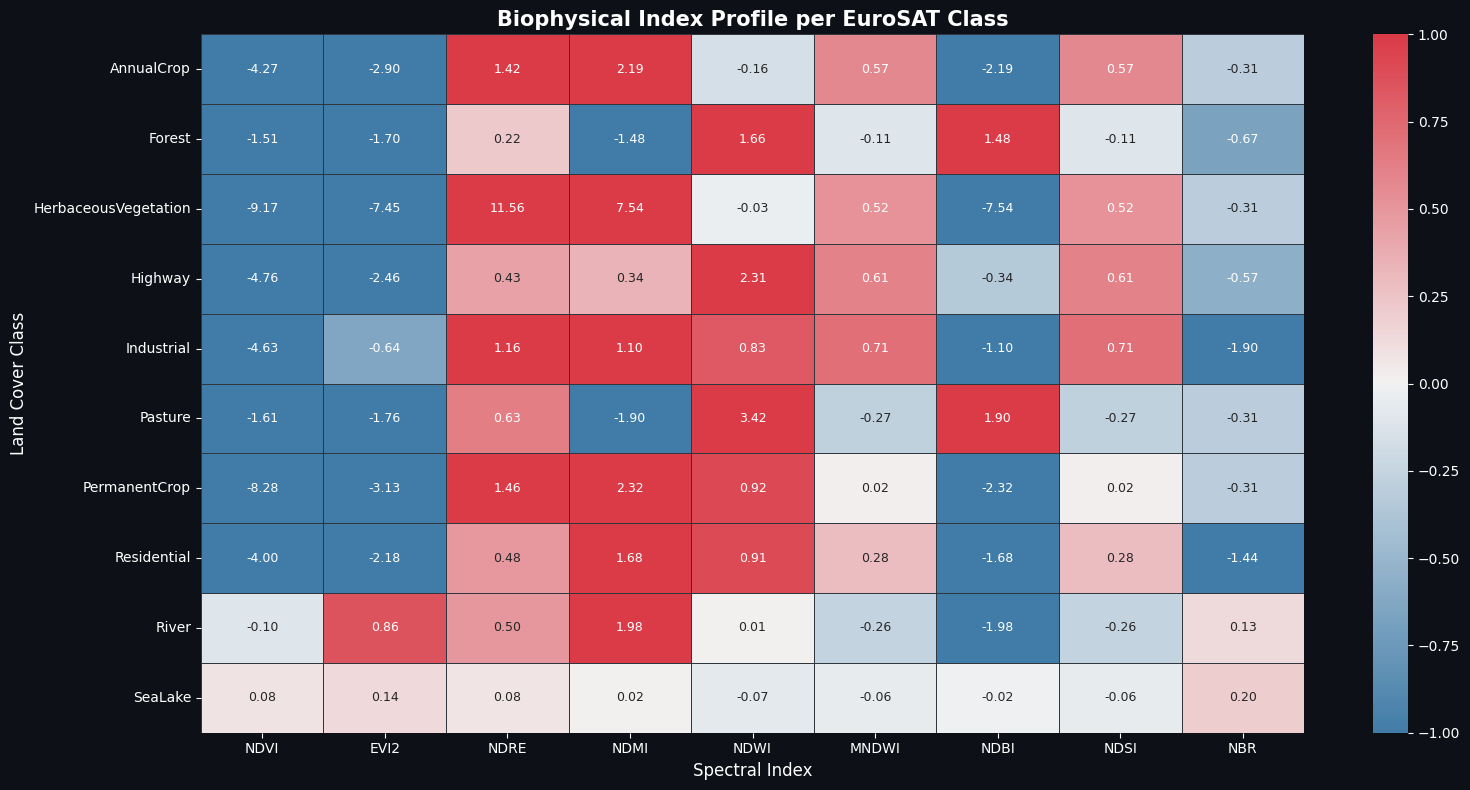

✅ Saved → ../outputs/04_index_class_profiles.png


In [20]:
# ─── Section 4C: Index Profile Per Class ──────────────────────────────────────
# Full index profile for all classes
all_class_indices = {}
for cls_name in EUROSAT_CLASSES:
    raw_patch = load_or_generate_patch(cls_name, MS_ROOT, seed=99)
    processed  = preprocess_ms_patch(raw_patch, BAND_NAMES)
    all_idx    = compute_spectral_indices(processed, BAND_NAMES)  # (9, H, W)
    all_class_indices[cls_name] = {name: float(all_idx[i].mean()) for i, name in enumerate(INDEX_NAMES)}

profile_df = pd.DataFrame(all_class_indices).T  # (10 classes, 9 indices)

# Heatmap visualization
fig, ax = plt.subplots(figsize=(16, 8), facecolor='#0d1117')
ax.set_facecolor('#161b22')

import seaborn as sns
cmap_diverge = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(
    profile_df,
    annot=True,
    fmt='.2f',
    cmap=cmap_diverge,
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    linecolor='#30363d',
    annot_kws={'size': 9},
)
ax.set_title('Biophysical Index Profile per EuroSAT Class',
             color='white', fontsize=15, fontweight='bold')
ax.set_xlabel('Spectral Index', color='white', fontsize=12)
ax.set_ylabel('Land Cover Class', color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=10)

plt.tight_layout()
plt.savefig('../outputs/04_index_class_profiles.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Saved → ../outputs/04_index_class_profiles.png')

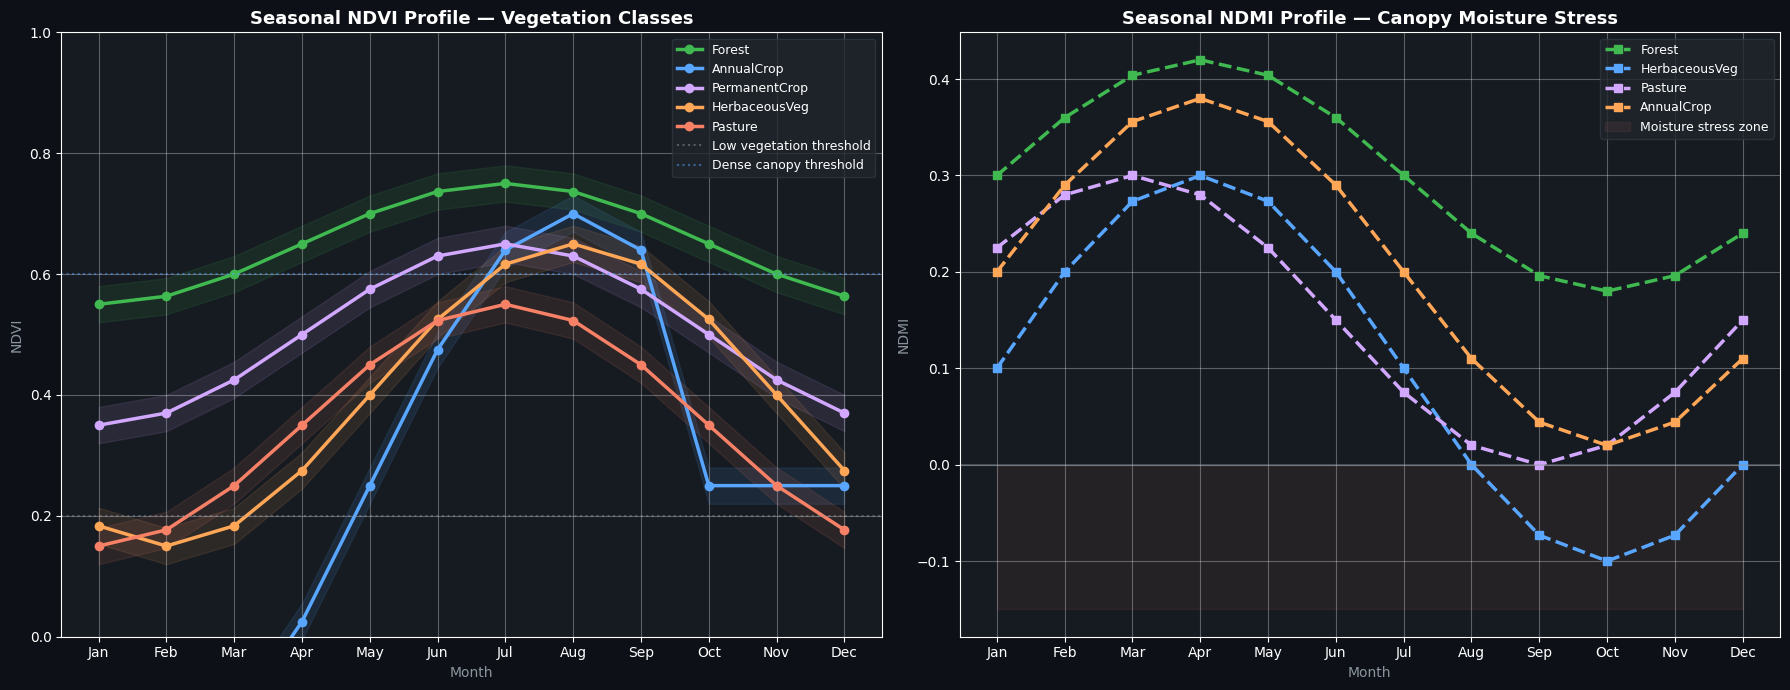

✅ Saved → ../outputs/04_seasonal_phenology.png


In [21]:
# ─── Section 4D: Vegetation Health Time-Series Simulation ─────────────────────
# Simulate NDVI seasonal variation for AnnualCrop vs Forest vs PermanentCrop
months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Modeled seasonal NDVI profiles (based on phenological patterns)
ndvi_profiles = {
    'Forest':          0.65 + 0.10 * np.sin(2 * np.pi * (months - 4) / 12),
    'AnnualCrop':      0.25 + 0.45 * np.sin(2 * np.pi * (months - 5) / 12) * (months < 10),
    'PermanentCrop':   0.50 + 0.15 * np.sin(2 * np.pi * (months - 4) / 12),
    'HerbaceousVeg':   0.40 + 0.25 * np.sin(2 * np.pi * (months - 5) / 12),
    'Pasture':         0.35 + 0.20 * np.sin(2 * np.pi * (months - 4) / 12),
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0d1117')

# NDVI seasonal curves
ax = axes[0]
ax.set_facecolor('#161b22')
colors_veg = ['#3fb950', '#58a6ff', '#d2a8ff', '#ffa657', '#f78166']

for (cls_name, ndvi_profile), color in zip(ndvi_profiles.items(), colors_veg):
    ax.plot(months, ndvi_profile, 'o-', color=color, linewidth=2.5, markersize=6,
            label=cls_name)
    ax.fill_between(months, ndvi_profile - 0.03, ndvi_profile + 0.03,
                    alpha=0.1, color=color)

ax.axhline(0.2, color='#8b949e', linestyle=':', alpha=0.5, label='Low vegetation threshold')
ax.axhline(0.6, color='#58a6ff', linestyle=':', alpha=0.5, label='Dense canopy threshold')
ax.set_xticks(months)
ax.set_xticklabels(month_labels, color='white')
ax.set_xlabel('Month', color='#8b949e')
ax.set_ylabel('NDVI', color='#8b949e')
ax.set_title('Seasonal NDVI Profile — Vegetation Classes', color='white', fontsize=13, fontweight='bold')
ax.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# NDMI (moisture) for Forest + HerbaceousVeg
ax2 = axes[1]
ax2.set_facecolor('#161b22')

ndmi_profiles = {
    'Forest':         0.30 - 0.12 * np.sin(2 * np.pi * (months - 7) / 12),  # drier in summer
    'HerbaceousVeg':  0.10 - 0.20 * np.sin(2 * np.pi * (months - 7) / 12),  # strong seasonal drying
    'Pasture':        0.15 - 0.15 * np.sin(2 * np.pi * (months - 6) / 12),
    'AnnualCrop':     0.20 - 0.18 * np.sin(2 * np.pi * (months - 7) / 12),
}

for (cls_name, ndmi_profile), color in zip(ndmi_profiles.items(), colors_veg):
    ax2.plot(months, ndmi_profile, 's--', color=color, linewidth=2.5, markersize=6,
             label=cls_name)

ax2.axhline(0, color='#8b949e', linestyle='-', alpha=0.4)
ax2.fill_between(months, -0.15, 0, alpha=0.07, color='#f78166', label='Moisture stress zone')
ax2.set_xticks(months)
ax2.set_xticklabels(month_labels, color='white')
ax2.set_xlabel('Month', color='#8b949e')
ax2.set_ylabel('NDMI', color='#8b949e')
ax2.set_title('Seasonal NDMI Profile — Canopy Moisture Stress', color='white', fontsize=13, fontweight='bold')
ax2.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/04_seasonal_phenology.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Saved → ../outputs/04_seasonal_phenology.png')

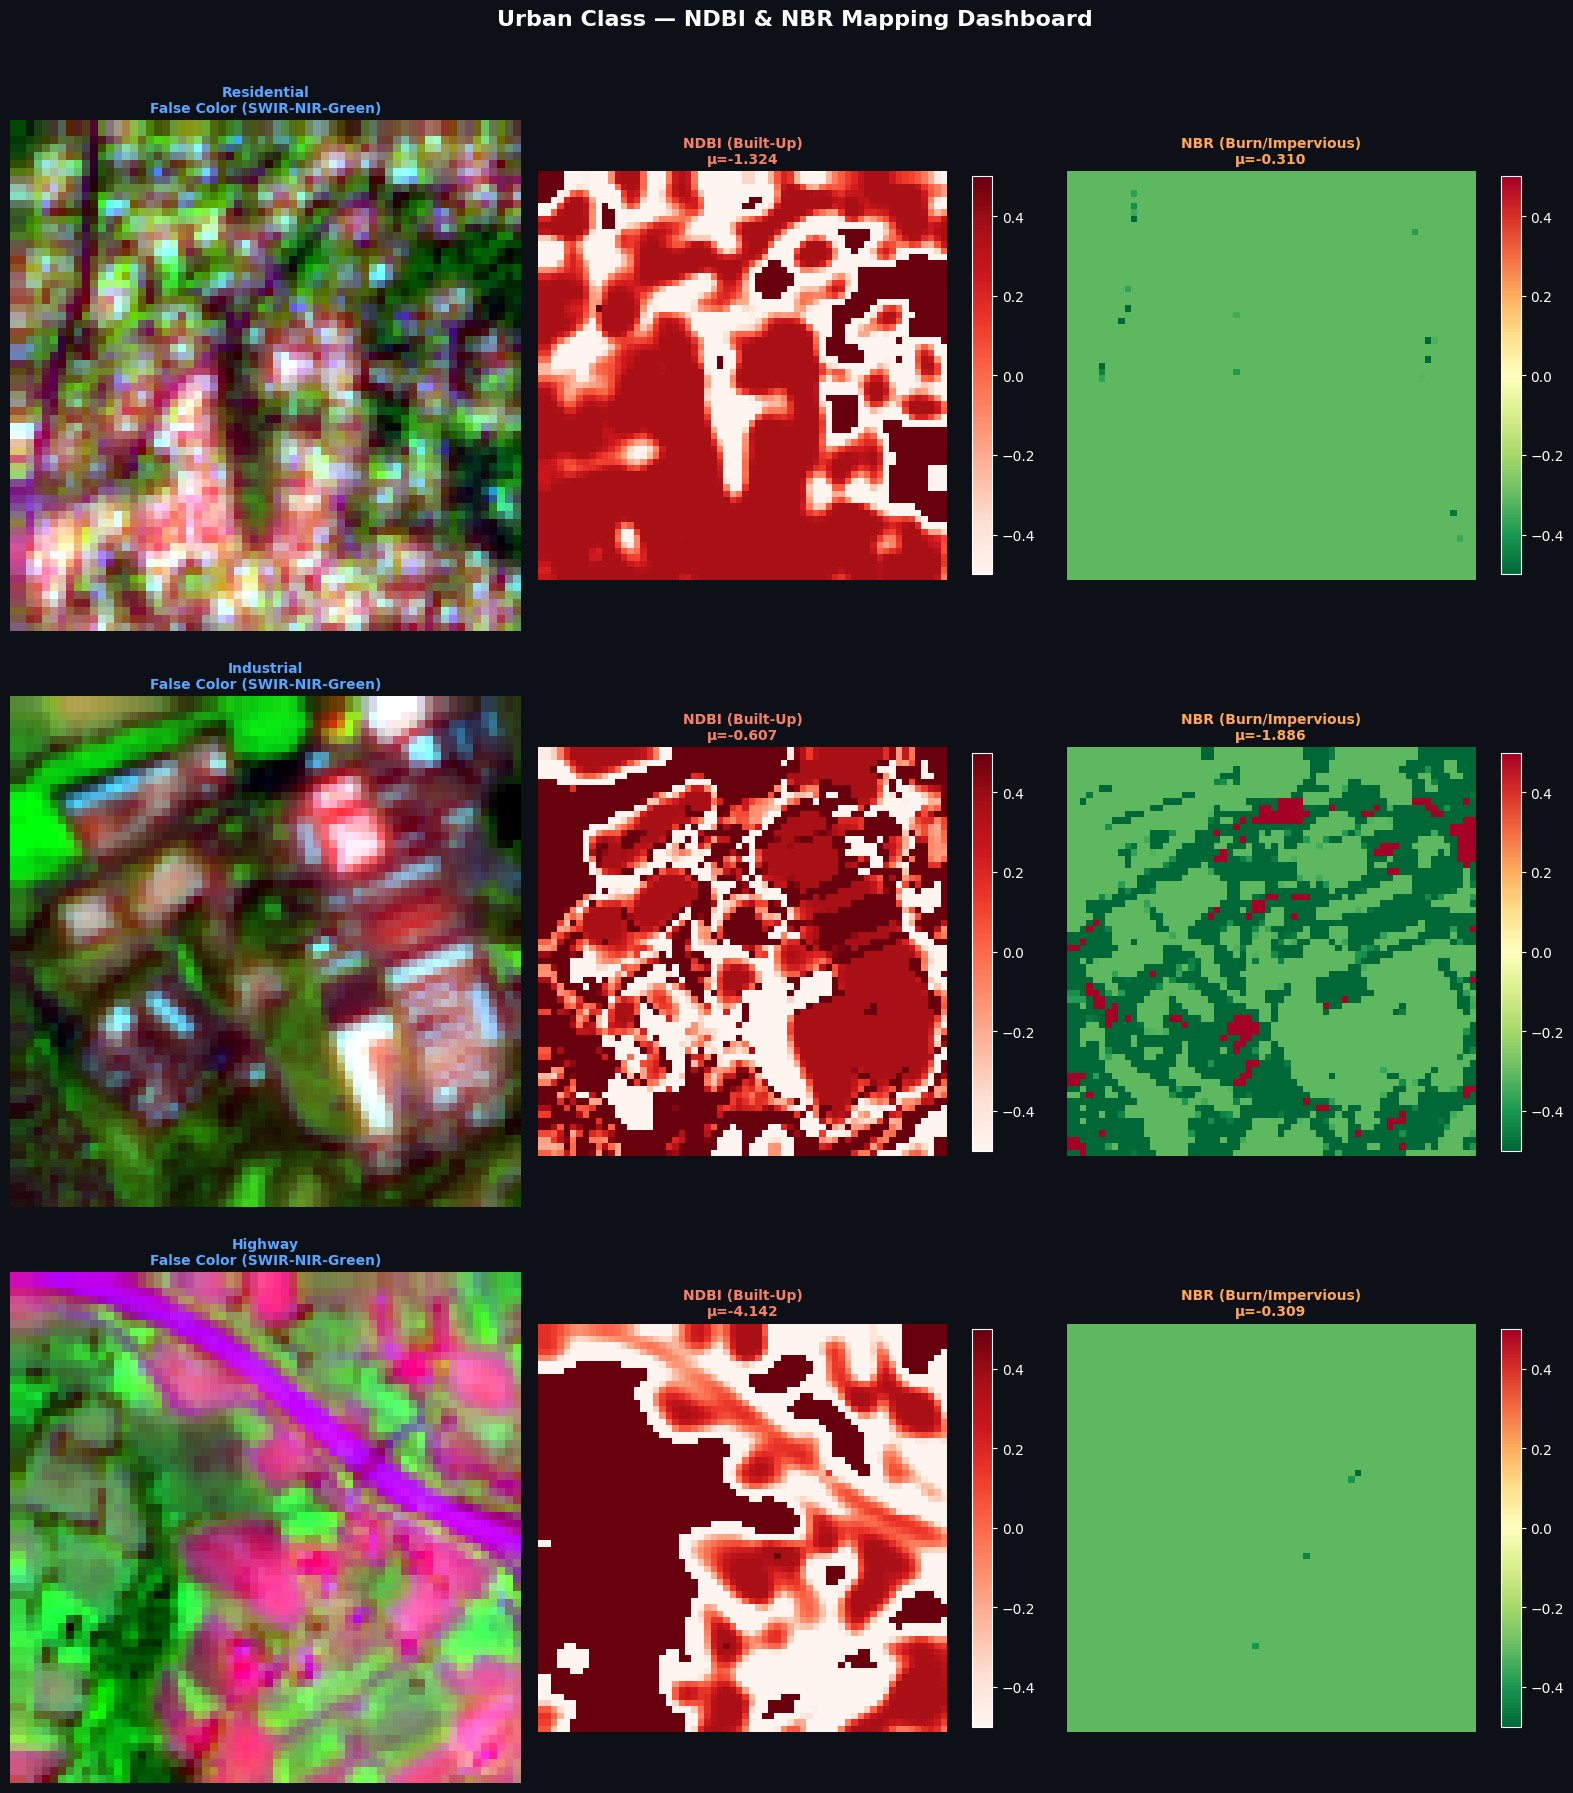

✅ Saved → ../outputs/04_urban_ndbi_mapping.png


In [22]:
# ─── Section 4E: Urban NDBI Mapping Dashboard ────────────────────────────────
urban_classes = ['Residential', 'Industrial', 'Highway']
fig, axes = plt.subplots(len(urban_classes), 3, figsize=(16, 6 * len(urban_classes)), facecolor='#0d1117')

for row, cls_name in enumerate(urban_classes):
    raw_patch = load_or_generate_patch(cls_name, MS_ROOT, seed=row * 13 + 5)
    processed  = preprocess_ms_patch(raw_patch, BAND_NAMES)
    all_idx    = compute_spectral_indices(processed, BAND_NAMES)
    idx_dict   = dict(zip(INDEX_NAMES, all_idx))
    false_color = make_false_color(raw_patch, BAND_NAMES, mode='swir_nir_green')
    
    # Col 1: False color
    ax = axes[row, 0]
    ax.imshow(false_color)
    ax.set_title(f'{cls_name}\nFalse Color (SWIR-NIR-Green)', color='#58a6ff', fontsize=10, fontweight='bold')
    ax.axis('off')
    
    # Col 2: NDBI
    ax2 = axes[row, 1]
    im2 = ax2.imshow(idx_dict['NDBI'], cmap='Reds', vmin=-0.5, vmax=0.5)
    ax2.set_title(f'NDBI (Built-Up)\nμ={idx_dict["NDBI"].mean():+.3f}', color='#f78166', fontsize=10, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, shrink=0.7)
    
    # Col 3: NBR (burn/impervious indicator)
    ax3 = axes[row, 2]
    im3 = ax3.imshow(idx_dict['NBR'], cmap='RdYlGn_r', vmin=-0.5, vmax=0.5)
    ax3.set_title(f'NBR (Burn/Impervious)\nμ={idx_dict["NBR"].mean():+.3f}', color='#ffa657', fontsize=10, fontweight='bold')
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, shrink=0.7)

plt.suptitle('Urban Class — NDBI & NBR Mapping Dashboard', color='white', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/04_urban_ndbi_mapping.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Saved → ../outputs/04_urban_ndbi_mapping.png')

## Section 4F: Sub-Patch Water Body Delineation — Otsu Thresholding

Standard image classification assigns a single label to each 64×64 patch.
For water classes (River, SeaLake), this loses sub-patch spatial structure —
the precise shoreline boundary, river width, or water fraction within a mixed patch.

By applying **Otsu's method** (automatic threshold selection that maximises
inter-class variance) to the MNDWI map of each water-class patch, we can
delineate the exact water/non-water boundary at pixel level. This converts
a classification output into a semantic segmentation mask suitable for:
- Flood monitoring and reservoir area estimation
- River width measurement and hydrological mapping
- Shoreline change detection over time

MNDWI = (B3 − B11) / (B3 + B11) suppresses built-up land and soil returns,
isolating open water more accurately than NDWI alone.

> Note: Index values are computed on raw DN (not reflectance), so Otsu
> thresholds are dataset-relative rather than absolute biophysical values.


In [ ]:
# ─── Section 4F: Otsu Water Body Delineation ─────────────────────────────────
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from utils import BAND_NAMES, compute_spectral_indices, INDEX_NAMES

def otsu_threshold(arr):
    """Compute Otsu threshold on a flattened 1D array."""
    flat = arr.flatten()
    # Use 256 bins over the data range
    counts, edges = np.histogram(flat, bins=256)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    total = counts.sum()
    sum_total = (bin_centers * counts).sum()

    best_thresh, best_var = 0.0, 0.0
    sum_bg, weight_bg = 0.0, 0

    for i in range(len(counts)):
        weight_bg += counts[i]
        if weight_bg == 0:
            continue
        weight_fg = total - weight_bg
        if weight_fg == 0:
            break
        sum_bg += bin_centers[i] * counts[i]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        var_between = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        if var_between > best_var:
            best_var = var_between
            best_thresh = bin_centers[i]
    return best_thresh

def load_patch(class_name, idx=0, split='train'):
    cls_dir = MS_ROOT / split / class_name
    tifs = sorted(cls_dir.glob('*.tif'))
    with rasterio.open(tifs[idx % len(tifs)]) as src:
        return src.read().astype(np.float32)

# ── Load water class patches ──────────────────────────────────────────────────
WATER_CLASSES = ['River', 'SeaLake']
N_PATCHES = 4   # patches per class

fig = plt.figure(figsize=(20, N_PATCHES * len(WATER_CLASSES) * 2.8),
                 facecolor='#0d1117')
fig.suptitle('Aurora — Sub-Patch Water Body Delineation (Otsu + MNDWI)',
             color='white', fontsize=15, fontweight='bold', y=1.01)

n_cols = 4  # False colour | MNDWI | Otsu mask | Overlay
row = 0

for cls_name in WATER_CLASSES:
    for patch_idx in range(N_PATCHES):
        raw = load_patch(cls_name, idx=patch_idx * 5)

        # Compute MNDWI from raw DN
        b3  = raw[BAND_NAMES.index('B3')].astype(np.float32)
        b11 = raw[BAND_NAMES.index('B11')].astype(np.float32)
        mndwi = (b3 - b11) / (b3 + b11 + 1e-8)

        # Otsu threshold on MNDWI
        thresh = otsu_threshold(mndwi)
        water_mask = (mndwi > thresh).astype(np.uint8)
        water_frac = water_mask.mean() * 100

        # False colour composite (NIR=B8, SWIR=B11, Green=B3)
        def norm_band(b):
            b = b.astype(np.float32)
            lo, hi = np.percentile(b, 2), np.percentile(b, 98)
            return np.clip((b - lo) / (hi - lo + 1e-8), 0, 1)

        b8  = raw[BAND_NAMES.index('B8')]
        rgb_false = np.stack([norm_band(b8), norm_band(b11), norm_band(b3)], axis=-1)

        # Plot row
        base = row * n_cols + 1

        # False colour
        ax = fig.add_subplot(N_PATCHES * len(WATER_CLASSES), n_cols, base)
        ax.imshow(rgb_false)
        ax.set_ylabel(f'{cls_name}\n#{patch_idx+1}',
                      color='#58a6ff', fontsize=9, fontweight='bold')
        ax.set_title('False Colour\n(NIR-SWIR-Green)', color='white', fontsize=8)
        ax.axis('off')

        # MNDWI map
        ax = fig.add_subplot(N_PATCHES * len(WATER_CLASSES), n_cols, base + 1)
        im = ax.imshow(mndwi, cmap='RdBu', vmin=-0.5, vmax=0.5)
        ax.set_title(f'MNDWI\n(thresh={thresh:.3f})', color='white', fontsize=8)
        ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

        # Otsu binary mask
        ax = fig.add_subplot(N_PATCHES * len(WATER_CLASSES), n_cols, base + 2)
        ax.imshow(water_mask, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f'Water Mask\n({water_frac:.1f}% water)', color='white', fontsize=8)
        ax.axis('off')

        # Overlay: mask contour on false colour
        ax = fig.add_subplot(N_PATCHES * len(WATER_CLASSES), n_cols, base + 3)
        ax.imshow(rgb_false)
        ax.contour(water_mask, levels=[0.5], colors=['cyan'], linewidths=1.5)
        ax.set_title('Shoreline Delineation\n(cyan = water boundary)',
                     color='white', fontsize=8)
        ax.axis('off')

        row += 1

plt.tight_layout()
plt.savefig('../outputs/04_otsu_water_delineation.png',
            dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'✅ Saved → ../outputs/04_otsu_water_delineation.png')

# ── Summary statistics ────────────────────────────────────────────────────────
print('\nWater fraction analysis (MNDWI + Otsu):')
for cls_name in WATER_CLASSES:
    fracs = []
    for i in range(20):
        try:
            raw = load_patch(cls_name, idx=i)
            b3  = raw[BAND_NAMES.index('B3')].astype(np.float32)
            b11 = raw[BAND_NAMES.index('B11')].astype(np.float32)
            mndwi = (b3 - b11) / (b3 + b11 + 1e-8)
            thresh = otsu_threshold(mndwi)
            fracs.append((mndwi > thresh).mean() * 100)
        except Exception:
            continue
    print(f'  {cls_name:8s}: mean water fraction = {np.mean(fracs):.1f}% '
          f'(±{np.std(fracs):.1f}%)  n={len(fracs)}')
print('\nKey insight: SeaLake patches show higher, more uniform water fraction')
print('than River patches, which contain mixed riparian pixels at boundaries.')


In [23]:
# ─── Final Summary ─────────────────────────────────────────────────────────────
print('\n' + '═' * 65)
print('🌍 AURORA — Notebook 04: Environmental Mapping Summary')
print('═' * 65)

print('\n📊 Per-Class Index Profile (mean values):')
print(profile_df.round(3).to_string())

print('\n📂 Output files generated:')
for fname in sorted(OUTPUT.glob('04_*.png')):
    print(f'   {fname.name}')

print('\n🔗 Pipeline Summary:')
print('   Crops    → NDVI + NDRE (vegetation vigor & chlorophyll)')
print('   Forest   → NDMI + NDVI (canopy moisture + biomass)')
print('   Urban    → NDBI (impervious surface density)')
print('   Water    → NDWI + MNDWI (water body extraction)')
print('   Snow     → NDSI (ice/snow detection)')
print('═' * 65)


═════════════════════════════════════════════════════════════════
🌍 AURORA — Notebook 04: Environmental Mapping Summary
═════════════════════════════════════════════════════════════════

📊 Per-Class Index Profile (mean values):
                       NDVI   EVI2    NDRE   NDMI   NDWI  MNDWI   NDBI   NDSI    NBR
AnnualCrop           -4.272 -2.901   1.423  2.195 -0.162  0.574 -2.195  0.574 -0.309
Forest               -1.514 -1.700   0.225 -1.477  1.657 -0.106  1.477 -0.106 -0.670
HerbaceousVegetation -9.166 -7.453  11.561  7.541 -0.034  0.522 -7.541  0.522 -0.309
Highway              -4.762 -2.458   0.434  0.342  2.311  0.606 -0.342  0.606 -0.570
Industrial           -4.625 -0.641   1.160  1.097  0.834  0.707 -1.097  0.707 -1.900
Pasture              -1.607 -1.756   0.632 -1.895  3.417 -0.275  1.895 -0.275 -0.312
PermanentCrop        -8.278 -3.133   1.459  2.315  0.922  0.022 -2.315  0.022 -0.311
Residential          -4.003 -2.177   0.485  1.682  0.906  0.282 -1.682  0.282 -1.443
River 